# Classificatore basato su SVM Lineari ed N-grammi

In questo secondo notebook l'analisi prosegue unendo le features con i risultati più promettenti dello step precedente.

In [ ]:
# Import dei moduli
import utils_svm
import os
from loguru import logger
from sklearn.dummy import DummyClassifier

In [ ]:
# Caricamento dei dati
data_path = "data.json"
dataset = utils_svm.load_data(data_path)
conllu_dir = "Profiling_UD\\16152"

### Definizione delle classi

In [3]:
class Document: 

    def __init__(self, document_path, dataset):

        self.document_path = document_path
        self.doc_id = None
        self.split = None
        self.author = None
        self.text = None
        self._load_doc_info(document_path, dataset)
        self.sentences = []
        self.features = None

    def _load_doc_info(self, document_path, dataset):
        self.doc_id = document_path.split('\\')[-1].split('.')[0]
        self.split = dataset[self.doc_id]['split']
        self.author = dataset[self.doc_id]['author']
        self.text = dataset[self.doc_id]['text']

    def add_sentence(self, sentence):
        self.sentences.append(sentence)
   
    def get_num_tokens(self):
        num_words = 0
        for sentence in self.sentences:
            num_words = num_words + sentence.get_num_tokens()
        return num_words
    
    def get_num_chars(self):
        num_chars = 0
        for sentence in self.sentences:
            sentence_char_len = sentence.get_num_chars()
            num_chars = num_chars + sentence_char_len
        return num_chars
    
    def __str__(self):
        return f"Document ID: {self.doc_id}, Author: {self.author}, Split: {self.split}"


In [4]:
class Sentence:
    def __init__(self):
        self.tokens = []

    def add_token(self, token):
        self.tokens.append(token)

    def get_words(self):
        return [token.word for token in self.tokens]

    def get_lemmas(self):
        return [token.lemma for token in self.tokens]

    def get_pos(self):
        return [token.pos for token in self.tokens]

    def get_num_tokens(self):
        return len(self.tokens)
    
    def get_num_chars(self):
        num_chars = 0
        for token in self.tokens:
            num_chars = num_chars+token.get_num_chars()
        num_chars = num_chars+self.get_num_tokens() -1
        return num_chars
    
    def __str__(self):
        return ' '.join([token.word for token in self.tokens])

In [5]:
class Token:

    def __init__(self, word, lemma, pos):
        self.word = word
        self.lemma = lemma
        self.pos = pos

    def get_num_chars(self):
        return len(self.word)

In [6]:
def load_document_sentences(document):
    sentence = Sentence()
    for line in open(document.document_path, 'r', encoding='UTF-8'):
            if line[0].isdigit():
                splitted_line = line.strip().split('\t')

                if '-' not in splitted_line[0]:
                    token = Token(splitted_line[1], splitted_line[2], splitted_line[3])
                    sentence.add_token(token)

            elif line =='\n':
                document.add_sentence(sentence)
                sentence =Sentence()

In [7]:
all_documents = []
pattern = r"# sent_id = (\d+)"

#listdir restituisce una lista di documenti presenti in una cartella
for file_name in os.listdir(conllu_dir): 
    file_path = os.path.join(conllu_dir, file_name)
    document = Document(file_path, dataset)
    load_document_sentences(document)
    all_documents.append(document)

In [8]:
sample_document = all_documents[657]
for sentence in sample_document.sentences[:5]:
    tokens = [token.word for token in sentence.tokens]
    print(' - '.join(tokens)+'\n')

When - Mr. - Wopsle - had - imparted - to - me - all - that - he - could - recall - or - I - extract - , - and - when - I - had - treated - him - to - a - little - appropriate - refreshment - , - after - the - fatigues - of - the - evening - , - we - parted - .

It - was - between - twelve - and - one - o’clock - when - I - reached - the - Temple - , - and - the - gates - were - shut - .

No - one - was - near - me - when - I - went - in - and - went - home - .



In [9]:
def extract_word_ngrams_from_sentence(word_ngrams, sentence, el,  n):
    if el == 'word': 
        all_words = sentence.get_words()

    elif el == 'lemma':
        all_words = sentence.get_lemmas()
    
    elif el == 'pos':
        all_words = sentence.get_pos()

    else:
        raise Exception(f'Invalid element {el}')
    
    for i in range(0, len(all_words) - n+1):
        ngram_words = all_words[i: i+n]
        ngram = f'{el.upper()}_{n}_' + '_'.join(ngram_words)

        if ngram not in word_ngrams:
            word_ngrams[ngram] = 1

        else:
            word_ngrams[ngram] +=1

    return word_ngrams

In [10]:
def extract_char_ngrams_from_sentence(char_ngrams, sentence, n):

    all_words = sentence.get_words()

    all_words = ' '.join(all_words)

    for i in range(0, len(all_words) - n+1):
        ngram_chars = all_words[i:i+n]
        ngram = f'CHAR_{n}_'+ngram_chars

        if ngram not in char_ngrams:
            char_ngrams[ngram] = 1

        else:
            char_ngrams[ngram] += 1

    return char_ngrams

### Estrazione e normalizzazione delle features dai documenti

In [11]:
def normalize_ngrams(ngrams_dict, doc_len):
    for ngram in ngrams_dict:
        ngrams_dict[ngram] = ngrams_dict[ngram]/float(doc_len)
        

L'allenamento di SVM sarà fatto su gruppi di 4 features prendendo le più informative dagli studi precedenti. I gruppi saranno:
- Words unigrams, words bigrams, char trigrams, char 4grams
- Words unigrams and bigrams, lemmas unigrams and bigrams
- word unigrams and bigrams, pos bigrams and trigrams
- word unigrams, lemma unigrams, pos trigrams and char trigrams
- word bigrams, lemma bigrams, pos bigrams, char 4grams

Per ogni task è poi addestrato un dummy classifier per avere una baseline di paragone.

### Primo Caso

In [ ]:
# Funzione la cui struttura è riutilizzata per ogni diverso caso di studio, estrae le features, le normalizza e le inserisce nella sezione features del dizionario
def first_case_study(all_documents):
    for document in all_documents:
        word_unigrams = dict()
        word_bigrams = dict()
        char_trigrams = dict()
        char_fourgrams = dict()
        for sentence in document.sentences:
            extract_word_ngrams_from_sentence(word_unigrams, sentence, 'word', 1)
            extract_word_ngrams_from_sentence(word_bigrams, sentence, 'word', 2)
            extract_char_ngrams_from_sentence(char_trigrams, sentence, 3)
            extract_char_ngrams_from_sentence(char_fourgrams, sentence, 4)

        num_words = document.get_num_tokens()
        num_chars = document.get_num_chars()
        normalize_ngrams(word_unigrams, num_words)
        normalize_ngrams(word_bigrams, num_words)
        normalize_ngrams(char_trigrams, num_chars)
        normalize_ngrams(char_fourgrams, num_chars)

        document_ngrams = word_unigrams | word_bigrams | char_trigrams | char_fourgrams

        document.features = document_ngrams

In [13]:
first_case_study(all_documents)
sample_document.features

{'WORD_1_When': 0.014285714285714285,
 'WORD_1_Mr.': 0.014285714285714285,
 'WORD_1_Wopsle': 0.014285714285714285,
 'WORD_1_had': 0.02857142857142857,
 'WORD_1_imparted': 0.014285714285714285,
 'WORD_1_to': 0.02857142857142857,
 'WORD_1_me': 0.02857142857142857,
 'WORD_1_all': 0.014285714285714285,
 'WORD_1_that': 0.014285714285714285,
 'WORD_1_he': 0.014285714285714285,
 'WORD_1_could': 0.014285714285714285,
 'WORD_1_recall': 0.014285714285714285,
 'WORD_1_or': 0.014285714285714285,
 'WORD_1_I': 0.05714285714285714,
 'WORD_1_extract': 0.014285714285714285,
 'WORD_1_,': 0.05714285714285714,
 'WORD_1_and': 0.05714285714285714,
 'WORD_1_when': 0.04285714285714286,
 'WORD_1_treated': 0.014285714285714285,
 'WORD_1_him': 0.014285714285714285,
 'WORD_1_a': 0.014285714285714285,
 'WORD_1_little': 0.014285714285714285,
 'WORD_1_appropriate': 0.014285714285714285,
 'WORD_1_refreshment': 0.014285714285714285,
 'WORD_1_after': 0.014285714285714285,
 'WORD_1_the': 0.05714285714285714,
 'WORD_1_fa

Features pre cleaning:  3600
Numero features post filtro: 644
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.9566666666666667


C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy sul validation set: 0.842
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.88      0.80      0.84       500
       Eliot       0.86      0.79      0.82       500
        Hugo       0.80      0.93      0.86       500

    accuracy                           0.84      1500
   macro avg       0.85      0.84      0.84      1500
weighted avg       0.85      0.84      0.84      1500

Accuracy del DummyClassifier: 0.3373333333333333


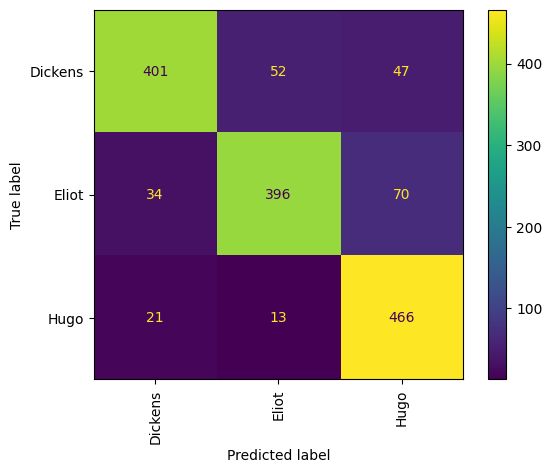

In [14]:
first_x_test, first_y_test, first_model = utils_svm.training_val(all_documents, 5)

### Secondo Caso

In [15]:
def second_case_study(all_documents):
    for document in all_documents:
        word_unigrams = dict()
        word_bigrams = dict()
        lem_unigrams = dict()
        lem_bigrams = dict()
        for sentence in document.sentences:
            extract_word_ngrams_from_sentence(word_unigrams, sentence, 'word', 1)
            extract_word_ngrams_from_sentence(word_bigrams, sentence, 'word', 2)
            extract_word_ngrams_from_sentence(word_unigrams, sentence, 'lemma', 1)
            extract_word_ngrams_from_sentence(word_bigrams, sentence, 'lemma', 2)

        num_words = document.get_num_tokens()

        normalize_ngrams(word_unigrams, num_words)
        normalize_ngrams(word_bigrams, num_words)
        normalize_ngrams(lem_unigrams, num_words)
        normalize_ngrams(lem_bigrams, num_words)

        document_ngrams = word_unigrams | word_bigrams | lem_unigrams | lem_bigrams


        document.features = document_ngrams

In [16]:
second_case_study(all_documents)
sample_document.features

{'WORD_1_When': 0.014285714285714285,
 'WORD_1_Mr.': 0.014285714285714285,
 'WORD_1_Wopsle': 0.014285714285714285,
 'WORD_1_had': 0.02857142857142857,
 'WORD_1_imparted': 0.014285714285714285,
 'WORD_1_to': 0.02857142857142857,
 'WORD_1_me': 0.02857142857142857,
 'WORD_1_all': 0.014285714285714285,
 'WORD_1_that': 0.014285714285714285,
 'WORD_1_he': 0.014285714285714285,
 'WORD_1_could': 0.014285714285714285,
 'WORD_1_recall': 0.014285714285714285,
 'WORD_1_or': 0.014285714285714285,
 'WORD_1_I': 0.05714285714285714,
 'WORD_1_extract': 0.014285714285714285,
 'WORD_1_,': 0.05714285714285714,
 'WORD_1_and': 0.05714285714285714,
 'WORD_1_when': 0.04285714285714286,
 'WORD_1_treated': 0.014285714285714285,
 'WORD_1_him': 0.014285714285714285,
 'WORD_1_a': 0.014285714285714285,
 'WORD_1_little': 0.014285714285714285,
 'WORD_1_appropriate': 0.014285714285714285,
 'WORD_1_refreshment': 0.014285714285714285,
 'WORD_1_after': 0.014285714285714285,
 'WORD_1_the': 0.05714285714285714,
 'WORD_1_fa

Features pre cleaning:  3600
Numero features post filtro: 178
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.9586111111111112


C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy sul validation set: 0.826
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.91      0.75      0.82       500
       Eliot       0.86      0.76      0.81       500
        Hugo       0.75      0.96      0.84       500

    accuracy                           0.83      1500
   macro avg       0.84      0.83      0.82      1500
weighted avg       0.84      0.83      0.82      1500

Accuracy del DummyClassifier: 0.33666666666666667


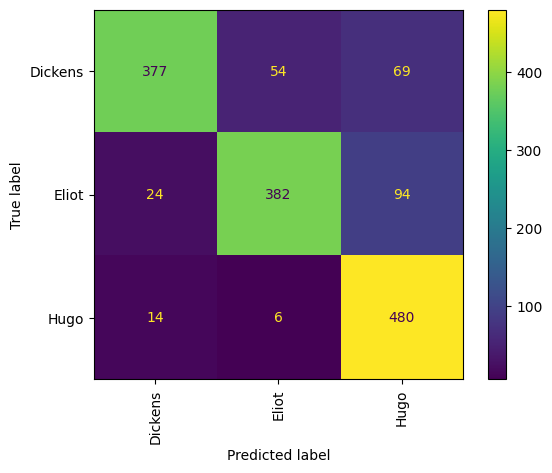

In [17]:
second_x_test, second_y_test, second_model = utils_svm.training_val(all_documents, 5)

### Terzo Caso

In [18]:
def third_case_study(all_documents):
    for document in all_documents:
        word_unigrams = dict()
        word_bigrams = dict()
        pos_bigrams = dict()
        pos_trigrams = dict()
        for sentence in document.sentences:
            extract_word_ngrams_from_sentence(word_unigrams, sentence, 'word', 1)
            extract_word_ngrams_from_sentence(word_bigrams, sentence, 'word', 2)
            extract_word_ngrams_from_sentence(word_unigrams, sentence, 'pos', 2)
            extract_word_ngrams_from_sentence(word_bigrams, sentence, 'pos', 3)

        num_words = document.get_num_tokens()

        normalize_ngrams(word_unigrams, num_words)
        normalize_ngrams(word_bigrams, num_words)
        normalize_ngrams(pos_bigrams, num_words)
        normalize_ngrams(pos_trigrams, num_words)

        document_ngrams = word_unigrams | word_bigrams | pos_bigrams | pos_trigrams


        document.features = document_ngrams

In [19]:
third_case_study(all_documents)
sample_document.features

{'WORD_1_When': 0.014285714285714285,
 'WORD_1_Mr.': 0.014285714285714285,
 'WORD_1_Wopsle': 0.014285714285714285,
 'WORD_1_had': 0.02857142857142857,
 'WORD_1_imparted': 0.014285714285714285,
 'WORD_1_to': 0.02857142857142857,
 'WORD_1_me': 0.02857142857142857,
 'WORD_1_all': 0.014285714285714285,
 'WORD_1_that': 0.014285714285714285,
 'WORD_1_he': 0.014285714285714285,
 'WORD_1_could': 0.014285714285714285,
 'WORD_1_recall': 0.014285714285714285,
 'WORD_1_or': 0.014285714285714285,
 'WORD_1_I': 0.05714285714285714,
 'WORD_1_extract': 0.014285714285714285,
 'WORD_1_,': 0.05714285714285714,
 'WORD_1_and': 0.05714285714285714,
 'WORD_1_when': 0.04285714285714286,
 'WORD_1_treated': 0.014285714285714285,
 'WORD_1_him': 0.014285714285714285,
 'WORD_1_a': 0.014285714285714285,
 'WORD_1_little': 0.014285714285714285,
 'WORD_1_appropriate': 0.014285714285714285,
 'WORD_1_refreshment': 0.014285714285714285,
 'WORD_1_after': 0.014285714285714285,
 'WORD_1_the': 0.05714285714285714,
 'WORD_1_fa

Features pre cleaning:  3600
Numero features post filtro: 195
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.9569444444444445
Accuracy sul validation set: 0.8393333333333334
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.89      0.80      0.84       500
       Eliot       0.88      0.76      0.82       500
        Hugo       0.77      0.96      0.85       500

    accuracy                           0.84      1500
   macro avg       0.85      0.84      0.84      1500
weighted avg       0.85      0.84      0.84      1500

Accuracy del DummyClassifier: 0.34933333333333333


C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


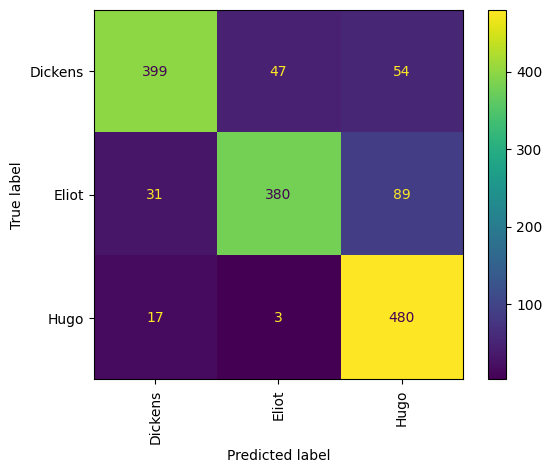

In [20]:
third_x_test, third_y_test, third_model = utils_svm.training_val(all_documents, 5)

### Quarto Caso: word unigrams, lemma unigrams, pos trigrams and char trigrams

In [21]:
def fourth_case_study(all_documents):
    for document in all_documents:
        word_unigrams = dict()
        lemma_unigrams = dict()
        pos_trigrams = dict()
        char_trigrams = dict()
        for sentence in document.sentences:
            extract_word_ngrams_from_sentence(word_unigrams, sentence, 'word', 1)
            extract_word_ngrams_from_sentence(lemma_unigrams, sentence, 'lemma', 1)
            extract_word_ngrams_from_sentence(pos_trigrams, sentence, 'pos', 3)
            extract_char_ngrams_from_sentence(char_trigrams, sentence, 3)

        num_words = document.get_num_tokens()
        num_char = document.get_num_chars()

        normalize_ngrams(word_unigrams, num_words)
        normalize_ngrams(lemma_unigrams, num_words)
        normalize_ngrams(pos_trigrams, num_words)
        normalize_ngrams(char_trigrams, num_char)

        document_ngrams = word_unigrams | lemma_unigrams | pos_trigrams | char_trigrams


        document.features = document_ngrams

In [22]:
fourth_case_study(all_documents)
sample_document.features

{'WORD_1_When': 0.014285714285714285,
 'WORD_1_Mr.': 0.014285714285714285,
 'WORD_1_Wopsle': 0.014285714285714285,
 'WORD_1_had': 0.02857142857142857,
 'WORD_1_imparted': 0.014285714285714285,
 'WORD_1_to': 0.02857142857142857,
 'WORD_1_me': 0.02857142857142857,
 'WORD_1_all': 0.014285714285714285,
 'WORD_1_that': 0.014285714285714285,
 'WORD_1_he': 0.014285714285714285,
 'WORD_1_could': 0.014285714285714285,
 'WORD_1_recall': 0.014285714285714285,
 'WORD_1_or': 0.014285714285714285,
 'WORD_1_I': 0.05714285714285714,
 'WORD_1_extract': 0.014285714285714285,
 'WORD_1_,': 0.05714285714285714,
 'WORD_1_and': 0.05714285714285714,
 'WORD_1_when': 0.04285714285714286,
 'WORD_1_treated': 0.014285714285714285,
 'WORD_1_him': 0.014285714285714285,
 'WORD_1_a': 0.014285714285714285,
 'WORD_1_little': 0.014285714285714285,
 'WORD_1_appropriate': 0.014285714285714285,
 'WORD_1_refreshment': 0.014285714285714285,
 'WORD_1_after': 0.014285714285714285,
 'WORD_1_the': 0.05714285714285714,
 'WORD_1_fa

Features pre cleaning:  3600
Numero features post filtro: 422
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.9563888888888888
Accuracy sul validation set: 0.84
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.90      0.78      0.83       500
       Eliot       0.87      0.80      0.83       500
        Hugo       0.78      0.95      0.85       500

    accuracy                           0.84      1500
   macro avg       0.85      0.84      0.84      1500
weighted avg       0.85      0.84      0.84      1500

Accuracy del DummyClassifier: 0.326


C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


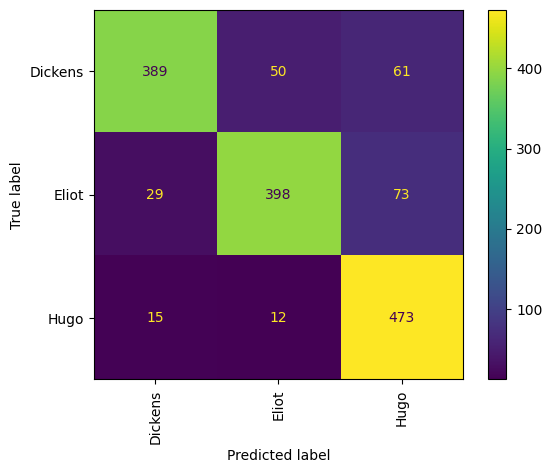

In [23]:
fourth_x_test, fourth_y_test, fourth_model = utils_svm.training_val(all_documents, 5)

### Quinto Caso: word bigrams, lemma bigrams, pos bigrams, char 4grams

In [24]:
def fifth_case_study(all_documents):
    for document in all_documents:
        word_bigrams = dict()
        lemma_bigrams = dict()
        pos_bigrams = dict()
        char_fourgrams = dict()
        for sentence in document.sentences:
            extract_word_ngrams_from_sentence(word_bigrams, sentence, 'word', 2)
            extract_word_ngrams_from_sentence(lemma_bigrams, sentence, 'lemma', 2)
            extract_word_ngrams_from_sentence(pos_bigrams, sentence, 'pos', 2)
            extract_char_ngrams_from_sentence(char_fourgrams, sentence, 4)

        num_words = document.get_num_tokens()
        num_char = document.get_num_chars()

        normalize_ngrams(word_bigrams, num_words)
        normalize_ngrams(lemma_bigrams, num_words)
        normalize_ngrams(pos_bigrams, num_words)
        normalize_ngrams(char_fourgrams, num_char)

        document_ngrams = word_bigrams | lemma_bigrams | pos_bigrams | char_fourgrams


        document.features = document_ngrams

In [25]:
fifth_case_study(all_documents)
sample_document.features

{'WORD_2_When_Mr.': 0.014285714285714285,
 'WORD_2_Mr._Wopsle': 0.014285714285714285,
 'WORD_2_Wopsle_had': 0.014285714285714285,
 'WORD_2_had_imparted': 0.014285714285714285,
 'WORD_2_imparted_to': 0.014285714285714285,
 'WORD_2_to_me': 0.014285714285714285,
 'WORD_2_me_all': 0.014285714285714285,
 'WORD_2_all_that': 0.014285714285714285,
 'WORD_2_that_he': 0.014285714285714285,
 'WORD_2_he_could': 0.014285714285714285,
 'WORD_2_could_recall': 0.014285714285714285,
 'WORD_2_recall_or': 0.014285714285714285,
 'WORD_2_or_I': 0.014285714285714285,
 'WORD_2_I_extract': 0.014285714285714285,
 'WORD_2_extract_,': 0.014285714285714285,
 'WORD_2_,_and': 0.02857142857142857,
 'WORD_2_and_when': 0.014285714285714285,
 'WORD_2_when_I': 0.04285714285714286,
 'WORD_2_I_had': 0.014285714285714285,
 'WORD_2_had_treated': 0.014285714285714285,
 'WORD_2_treated_him': 0.014285714285714285,
 'WORD_2_him_to': 0.014285714285714285,
 'WORD_2_to_a': 0.014285714285714285,
 'WORD_2_a_little': 0.01428571428571

Features pre cleaning:  3600
Numero features post filtro: 417
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.9508333333333333
Accuracy sul validation set: 0.8473333333333334
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.86      0.82      0.84       500
       Eliot       0.90      0.79      0.84       500
        Hugo       0.80      0.93      0.86       500

    accuracy                           0.85      1500
   macro avg       0.85      0.85      0.85      1500
weighted avg       0.85      0.85      0.85      1500

Accuracy del DummyClassifier: 0.3506666666666667


C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


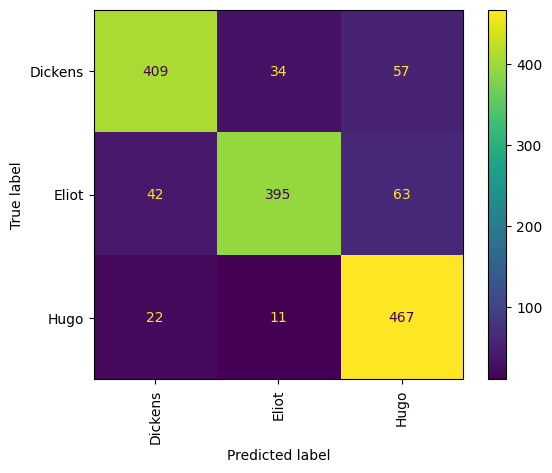

In [26]:
fifth_x_test, fifth_y_test, fifth_model = utils_svm.training_val(all_documents, 5)

## Performance sul Test Set

Accuracy sul test set: 0.7239732569245463
Classification report sul test set:               precision    recall  f1-score   support

     Dickens       0.80      0.49      0.61       698
       Eliot       0.63      0.74      0.68       698
        Hugo       0.77      0.94      0.85       698

    accuracy                           0.72      2094
   macro avg       0.74      0.72      0.71      2094
weighted avg       0.74      0.72      0.71      2094



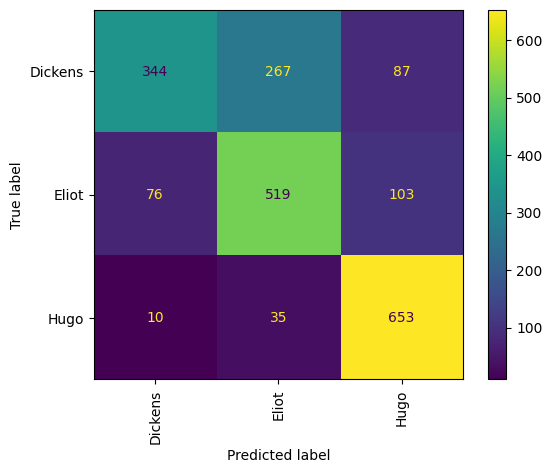

In [28]:
y_pred = utils_svm.predict(fifth_model, fifth_x_test, fifth_y_test, split = 'test set')